# Gold-Blind Teacher Supervision

A GPT-5.4 teacher selects retrieval-relevant history spans without access to gold passages. Their retrieval value is evaluated at B64 on the same 600 training-member development queries as Notebook 03, and labels are obtained for eligible TopiOCQA train and development data. Following the thesis, $q_t$ is the current query, $H_t$ the preceding history, $\widehat H_t$ the selected history, and $B$ the total T5 input budget. The `recency` arm is the baseline route $I_B$.

### Reproducible setup

The exact 600-query sample from Notebook 03 is reconstructed and verified by hash. Eligible TopiOCQA training and development queries are then prepared using fixed seeds, model settings, paths, and separate resumable caches.

Download the original train/dev labels and their manifests into `experiments/results/04_teacher/` as described in the README. Existing labels are reused, including the 600-query subset from the full training file. `ALLOW_TEACHER_API=False` prevents paid Teacher calls by default; set it to `True` only to explicitly opt into generating missing labels. The `RUN_*` flags remain enabled for evaluation and dataset preparation.


In [1]:
from __future__ import annotations

import hashlib
import inspect
import json
import os
import random
import sys
from pathlib import Path
from textwrap import dedent
from typing import Any

import numpy as np
import pandas as pd
import torch
from dotenv import load_dotenv
from IPython.display import Markdown, display
from tqdm.auto import tqdm


def resolve_project_root(start: Path) -> Path:
    configured = os.environ.get("ROCC_ROOT") or os.environ.get("MASTER_THESIS_PROJECT_ROOT")
    if configured:
        candidate = Path(configured).expanduser().resolve()
        if not (candidate / "experiments" / "rocc").is_dir():
            raise FileNotFoundError(f"Configured ROCC checkout is missing: {candidate}")
        return candidate
    for candidate in (start, *start.parents):
        if (candidate / "experiments" / "rocc").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Open this notebook from your ROCC checkout, or set ROCC_ROOT to it. "
        "In Colab, first clone the public repository over HTTPS or authenticate "
        "your own private checkout; no private clone or deploy key is assumed."
    )


PROJECT_ROOT = resolve_project_root(Path.cwd())
os.environ["MASTER_THESIS_PROJECT_ROOT"] = str(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
ENV_FILE = PROJECT_ROOT / ".env"
load_dotenv(ENV_FILE, override=False)

from experiments.rocc import (
    TEACHER_METRIC_COLUMNS,
    CachedIterCQRBM25Config,
    CachedIterCQRBM25Pipeline,
    TeacherProtocolConfig,
    TeacherRunner,
    TopiOCQAConversationSample as Sample,
    TopiOCQATurn as TurnText,
    add_conversation_columns,
    build_depth_eligible_population,
    build_topiocqa_conversation_samples,
    load_itercqr_tokenizer,
    load_topiocqa_frame,
    paired_bootstrap_mean_ci,
    resolve_topiocqa_resources,
    run_teacher_arm_evaluation,
    select_depth_balanced_population,
)


SEED = 13
RUN_TEACHER_600 = True
RUN_FULL_TRAIN = True
RUN_FULL_DEV = True
ALLOW_TEACHER_API = False  # Explicit opt-in for paid label generation.

BUDGETS = (64, 128, 256, 512)
PRIMARY_BUDGET = 64
SAMPLE_PER_BIN = 100
EXPECTED_GATE_SIZE = 600
EXPECTED_FULL_SIZE = 38_432
EXPECTED_DEV_SIZE = 2_104
EXPECTED_GATE_HASH = "147e62c8a7f071356afd7da51dc2b61547837e321a43cb36e68b5a30f9fef0bb"

DEPTH_BIN_ORDER = (
    "d02_04",
    "d05_06",
    "d07_08",
    "d09_10",
    "d11_14",
    "d15_plus",
)
DEPTH_SELECTION_ORDER = tuple(reversed(DEPTH_BIN_ORDER))
DEPTH_BOUNDS = {
    "d02_04": (2, 4),
    "d05_06": (5, 6),
    "d07_08": (7, 8),
    "d09_10": (9, 10),
    "d11_14": (11, 14),
    "d15_plus": (15, None),
}

TEACHER_MODEL = (
    os.environ.get("AZURE_OPENAI_CHAT_DEPLOYMENT") or "gpt-5.4"
)
TEACHER_API_SURFACE = "azure_openai_v1"
TEACHER_SEED = 42
TEACHER_TEMPERATURE = 0.0
TEACHER_MAX_OUTPUT_TOKENS = 1_400
TEACHER_CONCURRENCY = 8

REWRITE_BATCH_SIZE = 16
RETRIEVAL_BATCH_SIZE = 64
RETRIEVAL_WORKERS = max(1, min(8, (os.cpu_count() or 2) // 2))
RETRIEVAL_TOP_K = 1_000
EVAL_KS = (3, 10, 100, 1000)
BOOTSTRAP_REPLICATES = 10_000

DATA_DIR = PROJECT_ROOT / "experiments" / "data" / "topiocqa"
MODEL_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "model"
    / "IterCQR"
    / "IterCQR Model"
)
BM25_INDEX_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "data"
    / "pyserini_bm25_lucene_topiocqa"
    / "lucene_index"
)
RESULT_DIR = PROJECT_ROOT / "experiments" / "results" / "04_teacher"
TEACHER_CACHE_DIR = PROJECT_ROOT / ".cache" / "master_thesis" / "04_teacher"
TEACHER_CACHE_DB = TEACHER_CACHE_DIR / "teacher_cache.sqlite3"
GATE_DATASET_PATH = (
    RESULT_DIR
    / "rocc_history_labels_topiocqa_train_600.jsonl"
)
FULL_DATASET_PATH = (
    RESULT_DIR
    / "rocc_history_labels_topiocqa_train.jsonl"
)
DEV_DATASET_PATH = (
    RESULT_DIR
    / "rocc_history_labels_topiocqa_dev.jsonl"
)
PIPELINE_CACHE_DB = (
    PROJECT_ROOT
    / ".cache"
    / "master_thesis"
    / "03_oracle_headroom_analysis"
    / "runtime_cache.sqlite3"
)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
TEACHER_CACHE_DIR.mkdir(parents=True, exist_ok=True)
PIPELINE_CACHE_DB.parent.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

with tqdm(
    total=1,
    desc="load TopiOCQA",
    unit="dataset",
    dynamic_ncols=True,
) as progress:
    resources = resolve_topiocqa_resources(DATA_DIR)
    topiocqa_frame = load_topiocqa_frame(resources)
    progress.update(1)
train_frame = topiocqa_frame.loc[
    topiocqa_frame["split"].eq("train")
].copy()
dev_frame = topiocqa_frame.loc[
    topiocqa_frame["split"].eq("dev")
].copy()
del topiocqa_frame

train_frame = add_conversation_columns(train_frame)
dev_frame = add_conversation_columns(dev_frame)
eligible_population = build_depth_eligible_population(
    train_frame,
    depth_bounds=DEPTH_BOUNDS,
    depth_bin_order=DEPTH_BIN_ORDER,
)
gate_frame = select_depth_balanced_population(
    eligible_population,
    depth_bin_order=DEPTH_BIN_ORDER,
    selection_order=DEPTH_SELECTION_ORDER,
    samples_per_bin=SAMPLE_PER_BIN,
    seed=SEED,
    progress=True,
)
population_ids = gate_frame["sample_id"].astype(str).tolist()
gate_hash = hashlib.sha256(
    "\n".join(sorted(population_ids)).encode("utf-8")
).hexdigest()

full_samples = build_topiocqa_conversation_samples(
    train_frame,
    minimum_history_depth=2,
    progress=True,
)
dev_samples = build_topiocqa_conversation_samples(
    dev_frame,
    minimum_history_depth=2,
    progress=True,
)
if (
    len(full_samples) != EXPECTED_FULL_SIZE
    or len(gate_frame) != EXPECTED_GATE_SIZE
    or gate_hash != EXPECTED_GATE_HASH
):
    raise RuntimeError(
        "TopiOCQA population does not match Notebook 03: "
        f"full={len(full_samples)}, gate={len(gate_frame)}, "
        f"hash={gate_hash}"
    )
if len(dev_samples) != EXPECTED_DEV_SIZE:
    raise RuntimeError(
        "Unexpected TopiOCQA development population: "
        f"{len(dev_samples)} instead of {EXPECTED_DEV_SIZE}"
    )

full_samples_by_id = {
    sample.sample_id: sample for sample in full_samples
}
gate_samples = [
    full_samples_by_id[sample_id] for sample_id in population_ids
]

display(
    pd.DataFrame(
        [
            {
                "train_queries": len(train_frame),
                "teacher_eligible": len(full_samples),
                "dev_queries": len(dev_frame),
                "dev_teacher_eligible": len(dev_samples),
                "gate_queries": len(gate_samples),
                "gate_conversations": gate_frame["conv_id"].nunique(),
                "gate_hash": gate_hash,
                "device": DEVICE,
                "env_file": str(ENV_FILE),
            }
        ]
    )
)


,train_queries,teacher_eligible,dev_queries,dev_teacher_eligible,gate_queries,gate_conversations,gate_hash,device,env_file
0,45450,38432,2514,2104,600,600,147e62c8a7f071356afd7da51dc2b61547837e321a43cb...,cuda:0,/.env


The 600-query training-member development sample reuses the conversation-disjoint training sample from Notebook 03. The released processed data provide training and development files; the paper-reported test split is unavailable in this release. Following the IterCQR protocol, the full 2,514-query development split is reserved for final evaluation. These 600 diagnostic queries remain part of student training. Teacher labeling of the official development split is restricted to its 2,104 queries with at least two previous turns. The hash verifies identical diagnostic sampling across Notebooks 03 and 04.

### Teacher labeling

The teacher receives the current query together with the complete preceding dialogue history. Each turn contains its turn number, question, and answer. From this context, the teacher resolves the referent of the current query and selects exact history passages that provide IterCQR with useful retrieval context.

The selected passages receive one of five semantic roles: `ENTITY` identifies the concrete referent, `CONCEPT` preserves the broader topic, `KEY_TERM` adds useful search vocabulary, `DEFINITION` retains explanatory information, and `RELATION_CUE` connects the referent to an event, action, time, or person.

The actual sample `train:3198:19` contains 18 preceding turns. Its final two turns are:

```text
T17
Q: what are the uses of the census data and research
A: Population projections could be made, to help plan for provision in local government and regions, to allocate funding and it could be used directly by university researchers, large businesses and local government offices.

T18
Q: was it used in medieval europe
A: Yes, The Domesday Book was undertaken in 1086 by William I of England so that he could properly tax the land he had recently conquered in medieval Europe and in 1183, a census was taken of the crusader Kingdom of Jerusalem.

Current query:
what is this book about
```

The teacher resolves `this book` to `The Domesday Book` and selects the following spans:

| Label | Selected text | Function |
|---|---|---|
| `ENTITY` | `The Domesday Book` | Identifies the concrete referent |
| `CONCEPT` | `the census data and research` | Preserves the broader topic |
| `KEY_TERM` | `medieval Europe` | Adds a retrieval-relevant search term |
| `DEFINITION` | `so that he could properly tax the land he had recently conquered in medieval Europe` | Preserves the book’s purpose |
| `RELATION_CUE` | `was undertaken in 1086 by William I of England` | Connects the referent to the event, date, and person |

The response format requires every selected span to contain its source turn, source field, semantic label, exact text, and justification. This creates structured JSON that can be aligned with the original history and enriched with character offsets and token coverage.

A protocol fingerprint records the exact prompt and response schema, while a separate fingerprint verifies the fixed system instruction. The protocol configuration combines these instructions with the Azure GPT deployment, temperature 0, seed 42, and a maximum of 1,400 completion tokens. The runner connects this protocol to the persistent SQLite cache and JSONL destinations. When API generation is explicitly enabled, missing annotations are generated by the Azure-hosted teacher, validated against the source history, and saved as reusable JSONL records.

The five labels stored here form the semantic span representation. Notebook 05 later projects the validated spans onto MiniLM tokens as either the six-class semantic taxonomy or the collapsed `O`, `B-KEEP`, and `I-KEEP` representation.

Reproducibility is pursued at the input, protocol, and artifact levels. The sample IDs, dialogue order, prompt text, JSON schema, system instruction, deployment name, seed, temperature, and output limit are fixed. Hashes identify the rendered prompt and labeling protocol, while every accepted response is stored with its model name, protocol hash, prompt hash, and token usage. SQLite and JSONL persistence ensure that subsequent runs reuse the original validated annotations instead of generating them again. The completed JSONL receives a dataset hash, allowing downstream notebooks to verify that they use exactly the same labels.

This provides exact reproducibility for downstream experiments as long as the preserved JSONL and manifest are reused. It does not guarantee that a fresh API generation from an empty cache will reproduce the same spans. The request fixes `seed=42` and `temperature=0`, which reduce sampling variation, but the historical run records no backend `system_fingerprint`. The Azure deployment may also receive backend or model-snapshot changes, and concurrent requests can alter JSONL row order. OpenAI therefore describes deterministic generation as a best-effort property and recommends pinned model versions and evaluation rather than assuming identical regeneration ([OpenAI API documentation](https://developers.openai.com/api/reference/overview#backwards-compatibility)). The reproducible research artifact is consequently the validated and hashed JSONL dataset, not the assumption that the remote teacher can regenerate it identically.

In [ ]:
LABELS = {
    "ENTITY",
    "CONCEPT",
    "KEY_TERM",
    "DEFINITION",
    "RELATION_CUE",
}


def build_prompt(sample: Sample) -> str:
    history_block = "\n\n".join(
        (
            f"T{turn.turn_id}\n"
            f"Q: {turn.question}\n"
            f"A: {turn.answer}"
        )
        for turn in sample.history
    )
    allowed_turn_ids = [turn.turn_id for turn in sample.history]
    return f"""You label extractive history-compression spans for a conversational retrieval rewrite model.

Use ONLY the current query and visible history below. Do not use outside knowledge, gold answers, passage text, or retrieval results.

Goal:
Select the set of exact substrings from the HISTORY that should be kept under a small token budget so a downstream T5 query rewriter can resolve the current query for sparse retrieval. Completeness of retrieval-relevant content matters more than minimality.

Allowed labels:
- ENTITY: named entities, canonical names, titles, dates, organizations, people, places, works, species/taxa, group names.
- CONCEPT: abstract concepts, theories, ideas, processes, events, or named-like topics that are not proper named entities, e.g. "social contract", "catabolism", "human metabolism".
- KEY_TERM: short non-entity lexical anchors or domain terms that are useful for sparse retrieval, e.g. "hormones", "cast", "music labels". Use only when ENTITY or CONCEPT alone is insufficient.
- DEFINITION: short definitional/descriptive answer spans that are not named entities but are essential to disambiguate the current query.
- RELATION_CUE: very short exact relation/predicate cues that connect selected spans to the current query, e.g. "created", "founded", "released", "plays", "singer", "given". Use sparingly.

Rules:
- First silently resolve what the current query refers to. Pronouns and elliptical follow-ups almost always refer to the topic of the most recent turns, not to earlier topics; after a topic switch, prefer the newest coherent topic. All selected spans must be about this resolved referent.
- Every span text must be copied exactly from one history question or answer.
- Use only these turn_id values: {json.dumps(allowed_turn_ids)}.
- The returned sample_id must be exactly "{sample.sample_id}".
- Do not paraphrase.
- Do not create fluent compressed sentences.
- Do not select spans from current_query. Select only from HISTORY.
- Empty spans are allowed only if no exact history span can plausibly identify the referent, topic, or domain of the current query.
- For elliptical or pronominal current queries using words like "it", "this", "these", "he", "she", "they", "the film", "the song", or short follow-ups like "how", select at least one best antecedent/topic span from recent HISTORY.
- For one-word follow-ups such as "how", "why", "when", "where", "who", or "what", first resolve against the immediately previous history turn. Keep the previous question's predicate/topic cue when needed, e.g. "die", "stored", "born", plus the canonical antecedent from earlier history.
- When the current query asks about an attribute or event (born, died, founded, released, married, location, date), also select the exact answer substring where that attribute is stated, including full canonical names, alternate names, places, and dates. The rewriter can only use words you select; too little context forces it to invent unrelated words that hurt retrieval.
- Prefer ENTITY or CONCEPT spans. Add KEY_TERM spans for non-entity domain words that help retrieval. Add DEFINITION spans for short answer content that identifies or disambiguates the topic. Add RELATION_CUE spans when the relation connects selected spans to the current query.
- Prefer completeness over minimality: include every span that materially improves sparse retrieval - the canonical topic entity, supporting entities, aliases and disambiguators, definitional answer content, and short relation cues.
- Aim for roughly 20 to 40 kept words in total across all spans when the history contains that much relevant content. Never pad with irrelevant or repeated text; with little relevant history, fewer words are correct.
- Do not return only a single entity when the current query asks for concept, origin, purpose, reason, meaning, objective, or "what is/what was" information and the history contains a short definitional answer span. In that case, include the referent ENTITY plus the shortest useful DEFINITION span.
- Mandatory DEFINITION check: if current_query contains "concept", "origin", "purpose", "meaning", "objective", or "why", and any previous history question asks "why is/was", "what is/was", "what are/were", or asks what something is given for/about, select one exact answer substring as DEFINITION unless the answer is empty or UNANSWERABLE.
- If the current query asks "by whom/created by/founded by/composed by/played by", include the target entity and, when visible, the relation cue or definition that makes that target entity unambiguous.
- Before returning, check whether a downstream query rewriter could form a specific retrieval query from your spans alone. If not, add one short DEFINITION or RELATION_CUE span from the history.
- Return JSON only. Do not copy an empty spans template when a useful antecedent/topic exists.

Sample:
sample_id: {sample.sample_id}
current_query: {sample.current_query}

HISTORY:
{history_block}

Return a JSON object matching the schema with sample_id "{sample.sample_id}" and your selected spans.
"""


def output_schema() -> dict[str, Any]:
    return {
        "type": "object",
        "additionalProperties": False,
        "required": ["sample_id", "spans"],
        "properties": {
            "sample_id": {"type": "string"},
            "spans": {
                "type": "array",
                "items": {
                    "type": "object",
                    "additionalProperties": False,
                    "required": [
                        "turn_id",
                        "field",
                        "label",
                        "text",
                        "reason",
                    ],
                    "properties": {
                        "turn_id": {"type": "integer"},
                        "field": {
                            "type": "string",
                            "enum": ["question", "answer"],
                        },
                        "label": {
                            "type": "string",
                            "enum": sorted(LABELS),
                        },
                        "text": {"type": "string"},
                        "reason": {"type": "string"},
                    },
                },
            },
        },
    }


TEACHER_SYSTEM_PROMPT = (
    "You create strict extractive labels for "
    "conversational retrieval. Return only valid "
    "JSON matching the requested schema."
)
EXPECTED_SYSTEM_PROMPT_SHA256 = (
    "16dafffd39356a6051b6f07bc258bfec1aec00fc9de4543f10582e11f80e4266"
)

TEACHER_PROTOCOL_HASH = hashlib.sha256(
    (
        inspect.getsource(build_prompt)
        + json.dumps(output_schema(), sort_keys=True)
        + "\n"
        + json.dumps({"seed": TEACHER_SEED}, sort_keys=True)
    ).encode("utf-8")
).hexdigest()

teacher_protocol = TeacherProtocolConfig(
    model=TEACHER_MODEL,
    api_surface=TEACHER_API_SURFACE,
    protocol_hash=TEACHER_PROTOCOL_HASH,
    system_prompt=TEACHER_SYSTEM_PROMPT,
    prompt_builder=build_prompt,
    output_schema=output_schema(),
    allowed_labels=LABELS,
    seed=TEACHER_SEED,
    temperature=TEACHER_TEMPERATURE,
    max_output_tokens=TEACHER_MAX_OUTPUT_TOKENS,
    expected_system_prompt_sha256=(
        EXPECTED_SYSTEM_PROMPT_SHA256
    ),
)
teacher_runner = TeacherRunner(
    protocol=teacher_protocol,
    cache_db=TEACHER_CACHE_DB,
    concurrency=TEACHER_CONCURRENCY,
)

display(
    pd.DataFrame(
        [
            {
                "teacher_model": TEACHER_MODEL,
                "seed": TEACHER_SEED,
                "protocol_hash": TEACHER_PROTOCOL_HASH,
                "cache": str(TEACHER_CACHE_DB),
                "gate_jsonl": str(GATE_DATASET_PATH),
                "full_jsonl": str(FULL_DATASET_PATH),
                "dev_jsonl": str(DEV_DATASET_PATH),
            }
        ]
    )
)


,teacher_model,seed,protocol_hash,cache,gate_jsonl,full_jsonl,dev_jsonl
0,gpt-5.4,42,1bb7fbf0e48741db4ff349d075940041f7c471d0ca46ab...,/.cache/master_thesis/04_teacher/tea...,/experiments/...,/experiments/...,/experiments/...


### Teacher-label resolution and retrieval evaluation

The fixed 600-query diagnostic sample is resolved through `teacher_runner.resolve()`. Records are identified by `sample_id` and prompt hash. Previously validated records are reused from the gate JSONL, full-training JSONL, or SQLite cache. Missing records are generated by the Azure-hosted Teacher only when both `RUN_TEACHER_600=True` and `ALLOW_TEACHER_API=True`; retrieval evaluation remains controlled by `RUN_TEACHER_600`.

For every new API response, `resolve()` invokes `_request_one()`. The response is parsed under the strict JSON schema and passed to `validate()`, which executes the extractive alignment before the record is appended to the JSONL. Each proposed span is first searched in its declared turn and field. If it is absent there, the complete visible history is searched. A unique exact match is reassigned to its actual source. A unique case-insensitive match is restored to the source spelling. The accepted span receives its semantic label, source turn, source field, and field-local interval `[char_start, char_end)`. Proposals that cannot be resolved to a unique source are stored under `invalid_spans`.

The sample `train:3198:19` illustrates this correction. For the current query `what is this book about`, GPT-5.4 proposed the `CONCEPT` span `the census data and research` in the question of turn 18. That text is absent from the specified field. The validator found its unique source in the question of turn 17 and stored the corrected annotation with `turn_id = 17`, `field = question`, and `[char_start, char_end) = [21, 49)`. The original assignment is retained under `repaired_from`.

The JSONL therefore contains source-aligned semantic spans and character offsets. It also contains whitespace-token overlap labels for inspection. Notebook 05 later projects the validated character intervals onto MiniLM WordPieces to create the collapsed `O`, `B-KEEP`, and `I-KEEP` training labels.

Three history-selection arms are then constructed for every query. `teacher` retains the history words covered by accepted Teacher spans. `random_token` retains the same number of deterministically sampled history words and isolates the effect of content selection from selection length. `recency` supplies the complete history in recency order and lets the input budget determine how much context remains.

Each arm is serialized at B64, B128, B256, and B512, producing $600 \times 3 \times 4 = 7{,}200$ query–arm–budget inputs. Every input contains the current query and the history selected by its arm within the global token budget. The frozen IterCQR model rewrites these inputs, and the fixed BM25 index retrieves up to 1,000 passages per rewrite. Cached token inputs, rewrites, and rankings are reused, so IterCQR generation and BM25 retrieval run only for previously unseen inputs.

In [3]:
teacher_600, missing_teacher_600 = teacher_runner.resolve(
    gate_samples,
    allow_api=RUN_TEACHER_600 and ALLOW_TEACHER_API,
    dataset_path=GATE_DATASET_PATH,
    seed_paths=(FULL_DATASET_PATH,),
)
if missing_teacher_600 and not ALLOW_TEACHER_API:
    raise FileNotFoundError(
        "Teacher labels are missing. Download the original train/dev JSONL files and "
        "their manifests into experiments/results/04_teacher/ as described in the README, "
        "or explicitly set ALLOW_TEACHER_API=True to request paid generation."
    )
teacher_600_ready = len(teacher_600) == EXPECTED_GATE_SIZE
usage_600 = teacher_runner.usage_summary(teacher_600.values())
empty_teacher_rows = sum(
    not row["spans"] and not row["invalid_spans"]
    for row in teacher_600.values()
)
invalid_span_count = sum(
    len(row["invalid_spans"]) for row in teacher_600.values()
)

display(
    pd.DataFrame(
        [
            {
                "valid_teacher_rows": len(teacher_600),
                "missing_or_failed": len(missing_teacher_600),
                "valid_empty_rows": empty_teacher_rows,
                "invalid_spans": invalid_span_count,
                **usage_600,
            }
        ]
    )
)
print(
    "600-query JSONL:",
    GATE_DATASET_PATH,
    f"({len(teacher_600)}/{EXPECTED_GATE_SIZE})",
)

METRIC_COLUMNS = TEACHER_METRIC_COLUMNS
teacher_evaluation = None
serialized_inputs = pd.DataFrame()
pipeline_results = pd.DataFrame()

if RUN_TEACHER_600 and teacher_600_ready:
    with tqdm(
        total=1,
        desc="load IterCQR tokenizer",
        unit="model",
        dynamic_ncols=True,
    ) as progress:
        tokenizer = load_itercqr_tokenizer(MODEL_DIR)
        progress.update(1)

    cached_pipeline = CachedIterCQRBM25Pipeline(
        config=CachedIterCQRBM25Config(
            cache_db=PIPELINE_CACHE_DB,
            model_dir=MODEL_DIR,
            bm25_index_dir=BM25_INDEX_DIR,
            device=DEVICE,
            rewrite_batch_size=REWRITE_BATCH_SIZE,
            retrieval_batch_size=RETRIEVAL_BATCH_SIZE,
            retrieval_workers=RETRIEVAL_WORKERS,
            retrieval_top_k=RETRIEVAL_TOP_K,
            eval_ks=EVAL_KS,
            progress=True,
        ),
        tokenizer=tokenizer,
    )
    teacher_evaluation = run_teacher_arm_evaluation(
        samples=gate_samples,
        teacher_results=teacher_600,
        tokenizer=tokenizer,
        budgets=BUDGETS,
        seed=SEED,
        pipeline=cached_pipeline,
        gold_by_sample=gate_frame.set_index("sample_id")[
            "positive_ctx_passage_ids"
        ].to_dict(),
        progress=True,
    )
    cached_pipeline.close()
    serialized_inputs = teacher_evaluation.serialized_inputs
    pipeline_results = teacher_evaluation.pipeline_results
    display(teacher_evaluation.serialization_summary.round(3))
elif RUN_TEACHER_600:
    print(
        "Pipeline skipped: "
        f"{len(missing_teacher_600)} teacher results are missing."
    )
else:
    print("600-query experiment disabled.")


,valid_teacher_rows,missing_or_failed,valid_empty_rows,invalid_spans,prompt_tokens,completion_tokens,total_tokens
0,600,0,0,13,908985,102082,1011067


600-query JSONL: <project>/experiments/results/04_teacher/rocc_history_labels_topiocqa_train_600.jsonl (600/600)


,budget,arm,queries,unique_inputs,mean_input_length,truncation_rate
0,64,random_token,600,600,43.345,0.118
1,64,recency,600,600,63.248,0.945
2,64,teacher,600,600,38.577,0.100
3,128,random_token,600,600,44.933,0.002
4,128,recency,600,600,118.355,0.842
5,128,teacher,600,600,39.000,0.078
6,256,random_token,600,600,44.933,0.002
7,256,recency,600,600,191.850,0.707
8,256,teacher,600,600,39.000,0.078
9,512,random_token,600,600,44.933,0.002


Each arm contains all 600 training-member development queries, and `unique_inputs = 600` confirms that every query produces a distinct serialized IterCQR input within each arm and budget. `mean_input_length` includes the current query, prefixes, and retained history after T5 tokenization. `truncation_rate` is the proportion of queries for which at least one token was removed by either the 32-token segment limit or the global input budget.

The Teacher selection is compact. Its mean input length is 38.6 tokens at B64 and 39.0 tokens at all larger budgets. Only 10.0% of Teacher inputs are truncated at B64. The remaining 7.8% at B128–B512 results from the per-segment limit. The constant length above B64 shows that the selected spans are fixed and already fit within the larger budgets. Additional capacity is not filled with extra history.

The random-token control retains the same number of whitespace-delimited history tokens as the Teacher arm, but the selected words can require more T5 subword tokens. Its inputs are therefore slightly longer, averaging 44.9 tokens once the global budget no longer constrains them. This preserves selection quantity while testing whether the Teacher chose more useful tokens than a deterministic random selection of equal size.

Recency retains the complete history and is therefore strongly budget-constrained. At B64, its mean input length reaches 63.2 tokens and 94.5% of queries are truncated. Increasing the budget preserves progressively more history, but 65.2% remain affected at B512 because long histories and individual segments can still exceed their respective limits.

### Teacher example

This cell tries to select a reproducible, compact example containing all five labels.

The output shows the current query, relevant history turns, and each validated span with its label, source, exact text, and Teacher justification.

In [4]:
LABEL_ORDER = [
    "ENTITY",
    "CONCEPT",
    "KEY_TERM",
    "DEFINITION",
    "RELATION_CUE",
]


def labels_in(row: dict[str, Any]) -> set[str]:
    return {
        str(span["label"])
        for span in row.get("spans", [])
        if span.get("label") in LABELS
    }


candidates = list(teacher_600.values())
complete_candidates = [
    row for row in candidates
    if labels_in(row) == LABELS
]

# Prefer a compact example containing all five labels.
example = min(
    complete_candidates or candidates,
    key=lambda row: (
        -len(labels_in(row)),
        len(row.get("spans", [])),
        int(row.get("history_len", 0)),
        str(row["sample_id"]),
    ),
)

present_labels = labels_in(example)
relevant_turns = {
    int(span["turn_id"]) for span in example["spans"]
}

display(
    Markdown(
        f"""
### Teacher example: `{example["sample_id"]}`

**Current query:** {example["current_query"]}

**Included labels:** {", ".join(
    label for label in LABEL_ORDER if label in present_labels
)}
"""
    )
)

display(
    pd.DataFrame(
        [
            {
                "turn_id": turn["turn_id"],
                "question": turn["question"],
                "answer": turn["answer"],
            }
            for turn in example["history"]
            if int(turn["turn_id"]) in relevant_turns
        ]
    )
)

display(
    pd.DataFrame(example["spans"])[
        ["label", "turn_id", "field", "text", "reason"]
    ]
    .assign(
        label=lambda frame: pd.Categorical(
            frame["label"],
            categories=LABEL_ORDER,
            ordered=True,
        )
    )
    .sort_values(["label", "turn_id"])
    .reset_index(drop=True)
)


### Teacher example: `train:3198:19`

**Current query:** what is this book about

**Included labels:** ENTITY, CONCEPT, KEY_TERM, DEFINITION, RELATION_CUE


,turn_id,question,answer
0,17,what are the uses of the census data and research,"Population projections could be made, to help ..."
1,18,was it used in medieval europe,"Yes, The Domesday Book was undertaken in 1086 ..."


,label,turn_id,field,text,reason
0,ENTITY,18,answer,The Domesday Book,Canonical book/entity mentioned in the latest ...
1,CONCEPT,17,question,the census data and research,Most recent coherent topic antecedent for 'thi...
2,KEY_TERM,18,answer,medieval Europe,Useful domain anchor from the same turn matchi...
3,DEFINITION,18,answer,so that he could properly tax the land he had ...,Short purpose/aboutness description answering ...
4,RELATION_CUE,18,answer,was undertaken in 1086 by William I of England,Relation cue that identifies the book historic...


The query `what is this book about` is elliptical. The Teacher resolves `this book` to `The Domesday Book` and retains its census context, historical relation, purpose, and geographic anchor.

Together, the spans provide IterCQR with a specific referent and enough descriptive context to rewrite the query for retrieval. `medieval Europe` overlaps with the `DEFINITION` span, so the covered tokens are retained only once in the compressed input.

### Retrieval comparison

This cell aggregates MRR, nDCG@3, and Recall across the 600 queries for every arm and budget. The first table and bar chart compare the average retrieval quality of Teacher, Recency, and random-token selection.

Teacher performance is then compared query by query with two baselines:

- `Teacher − Recency` tests whether semantic compression improves on the standard history strategy.
- `Teacher − Random token` tests whether the selected content is more useful than an equal-sized random history selection.

The paired reciprocal-rank ($\mathrm{RR}$) difference is calculated for each query before averaging to obtain the $\mathrm{MRR}$ difference. This preserves the correspondence between the three inputs for each query. The code names the per-query column `MRR`, but it contains $\mathrm{RR}$ values. At the primary budget B64, $N_{\mathrm{boot}}=10{,}000$ paired query-level bootstrap resamples provide 95% confidence intervals. Deltas are also calculated for the larger budgets, but confidence intervals are produced only for B64.

All arm metrics and paired deltas are saved to `teacher_600_metrics.csv`. `full_train_supported` becomes `True` when both mean B64 comparisons are positive.

,budget,arm,n,MRR,nDCG@3,R@10,R@100,R@1000
0,64,random_token,600,0.0326,0.0251,0.0733,0.1433,0.2400
1,64,recency,600,0.1370,0.1287,0.2250,0.4067,0.5717
2,64,teacher,600,0.1704,0.1607,0.2917,0.5033,0.6667
3,128,random_token,600,0.0340,0.0286,0.0733,0.1450,0.2367
4,128,recency,600,0.1670,0.1542,0.2650,0.4817,0.6600
5,128,teacher,600,0.1717,0.1628,0.2933,0.5067,0.6733
6,256,random_token,600,0.0340,0.0286,0.0733,0.1450,0.2367
7,256,recency,600,0.1847,0.1745,0.3117,0.5333,0.7167
8,256,teacher,600,0.1717,0.1628,0.2933,0.5067,0.6733
9,512,random_token,600,0.0340,0.0286,0.0733,0.1450,0.2367


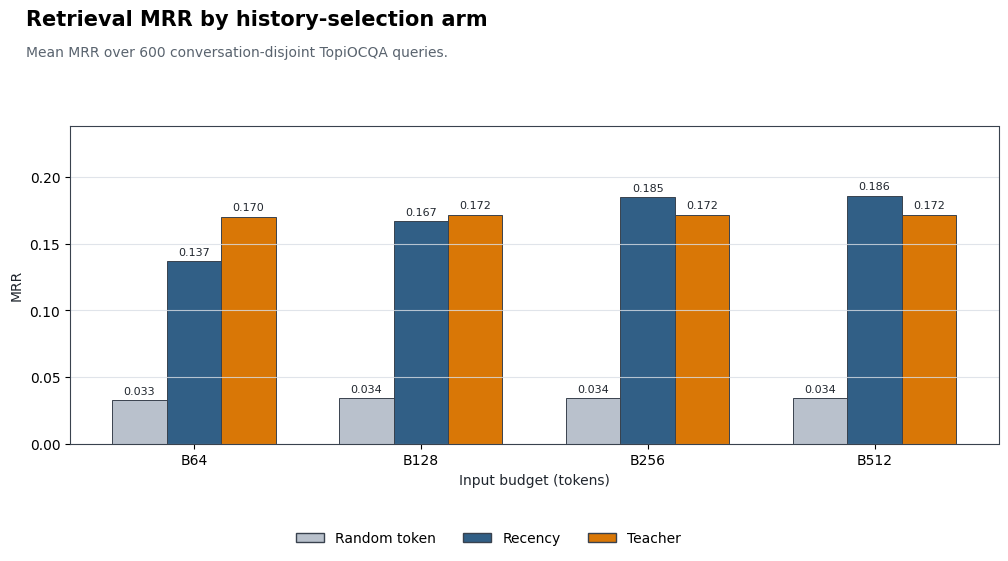

,budget,comparison,n,MRR_delta,ci95_low,ci95_high
0,64,Teacher − Recency,600,0.0333,0.0088,0.0578
1,64,Teacher − Random token,600,0.1378,0.1131,0.1634


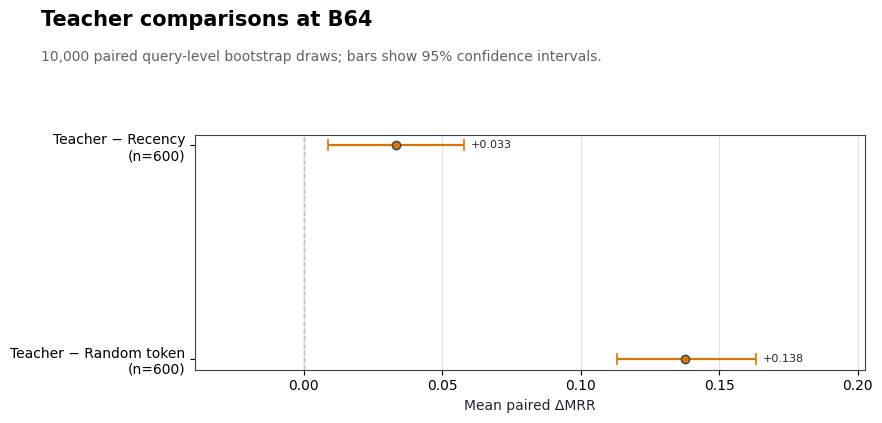

Results file: <project>/experiments/results/04_teacher/teacher_600_metrics.csv
Full training supported: True (RUN_FULL_TRAIN remains a manual decision)


In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#39424e",
        "axes.labelcolor": "#20262e",
        "axes.titlecolor": "#20262e",
        "grid.color": "#d9dee5",
        "grid.linewidth": 0.8,
        "font.size": 10,
    }
)

BLUE = "#315f86"
ORANGE = "#d97706"
GRAY = "#b9c1cc"
INK = "#20262e"
EDGE = "#39424e"

arm_metrics = pd.DataFrame()
delta_metrics = pd.DataFrame()
full_train_supported = False

if not pipeline_results.empty:
    arm_order = ("random_token", "recency", "teacher")
    arm_rank = {
        arm: index for index, arm in enumerate(arm_order)
    }

    arm_metrics = (
        pipeline_results.groupby(
            ["budget", "arm"],
            observed=True,
        )
        .agg(
            n=("sample_id", "size"),
            **{
                metric: (metric, "mean")
                for metric in METRIC_COLUMNS
            },
        )
        .reset_index()
        .assign(
            _arm_rank=lambda frame: frame["arm"].map(arm_rank)
        )
        .sort_values(
            ["budget", "_arm_rank"],
            kind="mergesort",
        )
        .drop(columns="_arm_rank")
        .reset_index(drop=True)
    )

    delta_rows: list[dict[str, Any]] = []
    for budget, frame in pipeline_results.groupby(
        "budget",
        observed=True,
    ):
        pivot = frame.pivot(
            index="sample_id",
            columns="arm",
            values="MRR",
        )

        for comparison_index, (baseline, label) in enumerate(
            (
                ("recency", "Teacher − Recency"),
                ("random_token", "Teacher − Random token"),
            )
        ):
            deltas = (
                pivot["teacher"] - pivot[baseline]
            ).to_numpy(dtype=np.float64)

            ci_low = np.nan
            ci_high = np.nan
            if int(budget) == PRIMARY_BUDGET:
                ci_low, ci_high = paired_bootstrap_mean_ci(
                    deltas,
                    seed=SEED + comparison_index,
                    replicates=BOOTSTRAP_REPLICATES,
                    progress_desc=f"bootstrap {label}",
                )

            delta_rows.append(
                {
                    "budget": int(budget),
                    "comparison": label,
                    "n": len(deltas),
                    "MRR_delta": float(deltas.mean()),
                    "ci95_low": ci_low,
                    "ci95_high": ci_high,
                }
            )

    delta_metrics = pd.DataFrame(delta_rows)
    primary_delta_metrics = (
        delta_metrics.loc[
            delta_metrics["budget"].eq(PRIMARY_BUDGET)
        ]
        .reset_index(drop=True)
    )

    arm_export = arm_metrics.assign(
        row_type="arm",
        comparison=pd.NA,
        MRR_delta=np.nan,
        ci95_low=np.nan,
        ci95_high=np.nan,
    )
    delta_export = delta_metrics.assign(
        row_type="delta",
        arm=pd.NA,
    )
    metrics_export = pd.concat(
        [arm_export, delta_export],
        ignore_index=True,
        sort=False,
    )

    metrics_path = (
        RESULT_DIR / "teacher_600_metrics.csv"
    )
    metrics_export.to_csv(metrics_path, index=False)

    primary_deltas = primary_delta_metrics.set_index(
        "comparison"
    )["MRR_delta"]
    full_train_supported = bool(
        primary_deltas.get(
            "Teacher − Recency",
            0.0,
        )
        > 0
        and primary_deltas.get(
            "Teacher − Random token",
            0.0,
        )
        > 0
    )

    # First table
    display(arm_metrics.round(4))

    # Bar chart: MRR by budget and arm
    arm_styles = (
        ("random_token", "Random token", GRAY),
        ("recency", "Recency", BLUE),
        ("teacher", "Teacher", ORANGE),
    )
    budget_order = [int(budget) for budget in BUDGETS]
    x = np.arange(len(budget_order))
    bar_width = 0.24

    fig, ax = plt.subplots(figsize=(10.5, 5.6))

    for arm_index, (arm, label, color) in enumerate(
        arm_styles
    ):
        values = (
            arm_metrics.loc[
                arm_metrics["arm"].eq(arm)
            ]
            .set_index("budget")
            .reindex(budget_order)["MRR"]
            .to_numpy(dtype=float)
        )
        offset = (
            arm_index - (len(arm_styles) - 1) / 2
        ) * bar_width
        bars = ax.bar(
            x + offset,
            values,
            width=bar_width,
            color=color,
            edgecolor=EDGE,
            linewidth=0.7,
            label=label,
        )
        ax.bar_label(
            bars,
            labels=[f"{value:.3f}" for value in values],
            padding=3,
            fontsize=8,
            color=INK,
        )

    max_mrr = float(arm_metrics["MRR"].max())
    ax.set_ylim(0, max(0.05, max_mrr * 1.28))
    ax.set_xticks(
        x,
        [f"B{budget}" for budget in budget_order],
    )
    ax.set_xlabel("Input budget (tokens)")
    ax.set_ylabel("MRR")
    ax.grid(axis="y", alpha=0.8)
    ax.grid(axis="x", visible=False)

    fig.suptitle(
        "Retrieval MRR by history-selection arm",
        x=0.06,
        y=0.99,
        ha="left",
        fontsize=15,
        fontweight="bold",
    )
    fig.text(
        0.06,
        0.925,
        (
            f"Mean MRR over {EXPECTED_GATE_SIZE} "
            "conversation-disjoint TopiOCQA queries."
        ),
        ha="left",
        va="top",
        color="#59636e",
    )
    fig.legend(
        handles=[
            Patch(
                facecolor=GRAY,
                edgecolor=EDGE,
                label="Random token",
            ),
            Patch(
                facecolor=BLUE,
                edgecolor=EDGE,
                label="Recency",
            ),
            Patch(
                facecolor=ORANGE,
                edgecolor=EDGE,
                label="Teacher",
            ),
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=3,
        frameon=False,
    )
    fig.tight_layout(rect=(0.03, 0.11, 1, 0.87))
    plt.show()

    # Second table: B64 only
    display(primary_delta_metrics.round(4))

    # Ladder/interval plot in the style of Notebook 03
    comparison_order = (
        "Teacher − Recency",
        "Teacher − Random token",
    )
    ladder_plot = (
        primary_delta_metrics.set_index("comparison")
        .reindex(comparison_order)
        .reset_index()
    )

    means = ladder_plot["MRR_delta"].to_numpy(
        dtype=float
    )
    lows = ladder_plot["ci95_low"].to_numpy(
        dtype=float
    )
    highs = ladder_plot["ci95_high"].to_numpy(
        dtype=float
    )
    y = np.arange(len(ladder_plot))
    valid = (
        np.isfinite(means)
        & np.isfinite(lows)
        & np.isfinite(highs)
    )

    fig, ax = plt.subplots(figsize=(9.2, 4.4))

    ax.errorbar(
        means[valid],
        y[valid],
        xerr=np.vstack(
            [
                np.maximum(
                    means[valid] - lows[valid],
                    0,
                ),
                np.maximum(
                    highs[valid] - means[valid],
                    0,
                ),
            ]
        ),
        fmt="o",
        markersize=6,
        color=ORANGE,
        markerfacecolor=ORANGE,
        markeredgecolor=EDGE,
        ecolor=ORANGE,
        elinewidth=1.6,
        capsize=4,
        capthick=1.2,
        zorder=3,
    )
    ax.axvline(
        0,
        color="#65727f",
        linewidth=1.0,
        linestyle="--",
        zorder=1,
    )

    finite_bounds = np.concatenate(
        [
            lows[valid],
            highs[valid],
            np.array([0.0]),
        ]
    )
    bound_min = float(finite_bounds.min())
    bound_max = float(finite_bounds.max())
    bound_span = max(bound_max - bound_min, 0.01)
    padding = bound_span * 0.24
    ax.set_xlim(
        bound_min - padding,
        bound_max + padding,
    )

    for index in y[valid]:
        row = ladder_plot.iloc[index]
        mean = float(row["MRR_delta"])

        if mean < 0:
            label_x = float(row["ci95_low"])
            label_offset = -5
            alignment = "right"
        else:
            label_x = float(row["ci95_high"])
            label_offset = 5
            alignment = "left"

        ax.annotate(
            f"{mean:+.3f}",
            xy=(label_x, index),
            xytext=(label_offset, 0),
            textcoords="offset points",
            ha=alignment,
            va="center",
            fontsize=8,
            color=INK,
        )

    ax.set_yticks(
        y,
        [
            f"{row.comparison}\n(n={int(row.n)})"
            for row in ladder_plot.itertuples(
                index=False
            )
        ],
    )
    ax.invert_yaxis()
    ax.set_xlabel("Mean paired ΔMRR")
    ax.grid(axis="x", alpha=0.8)
    ax.grid(axis="y", visible=False)

    fig.suptitle(
        f"Teacher comparisons at B{PRIMARY_BUDGET}",
        x=0.08,
        y=0.99,
        ha="left",
        fontsize=15,
        fontweight="bold",
    )
    fig.text(
        0.08,
        0.90,
        (
            f"{BOOTSTRAP_REPLICATES:,} paired query-level "
            "bootstrap draws; bars show 95% confidence intervals."
        ),
        ha="left",
        va="top",
        color="#59636e",
    )
    fig.tight_layout(rect=(0.03, 0.04, 1, 0.82))
    plt.show()

    print("Results file:", metrics_path)
    print(
        "Full training supported:",
        full_train_supported,
        "(RUN_FULL_TRAIN remains a manual decision)",
    )
else:
    print("No 600-query results are available.")

At B64, Teacher selection improves MRR from 0.13702 to 0.17035 over Recency, a paired gain of +0.03333 MRR or approximately 24.3%. The 95% confidence interval `[0.00884, 0.05779]` lies entirely above zero. Teacher also improves nDCG@3 and Recall at every reported cutoff.

Compared with the token-count-matched random control, Teacher gains +0.13777 MRR with a 95% confidence interval of `[0.11307, 0.16343]`. The improvement therefore comes from the selected semantic content rather than the number of retained history tokens.

Teacher recovers 68.1% of the MRR gap between B64 Recency and B512 Recency. Its results remain nearly constant above B128 because the fixed selected spans already fit within those budgets. Recency continues to gain from additional history and overtakes Teacher at B256.

These results support using the Teacher annotations as a supervision source for budget-constrained selection, particularly at B64.

### Full training-label generation

When `RUN_FULL_TRAIN=True`, the Teacher resolves annotations for all 38,432 eligible training queries.

Resolution follows a restartable order: existing full-training JSONL, the validated 600-query JSONL, SQLite cache, and finally the Azure Teacher API only if `ALLOW_TEACHER_API=True`. The 600 existing records are copied into the full dataset through `seed_paths`, preserving their original annotations and avoiding repeated API calls. Newly resolved records are validated and appended incrementally to the full JSONL.

If requests remain missing, the current progress is preserved and a later execution resumes from it. Once all records are available, `finalize_dataset()` verifies the expected row count, summarizes API usage and invalid spans, calculates the JSONL SHA-256 hash, and writes the accompanying manifest. The completed JSONL contains the validated semantic spans and character offsets that Notebook 05 later projects onto BIO training labels.

In [7]:
full_dataset_written = False
full_missing: list[str] = []

if RUN_FULL_TRAIN:
    if not full_train_supported:
        print(
            "Note: The two B64 deltas currently do not support "
            "full training. RUN_FULL_TRAIN is "
            "a manual override."
        )

    full_teacher, full_missing = teacher_runner.resolve(
        full_samples,
        allow_api=ALLOW_TEACHER_API,
        dataset_path=FULL_DATASET_PATH,
        seed_paths=(GATE_DATASET_PATH,),
    )
    if full_missing:
        print(
            "Full-training JSONL is still incomplete:",
            len(full_missing),
            "teacher results are missing. Run again.",
        )
        print(
            "Full-Train-JSONL:",
            FULL_DATASET_PATH,
            f"({len(full_teacher)}/{len(full_samples)})",
        )
    else:
        finalized_dataset = teacher_runner.finalize_dataset(
            full_teacher.values(),
            dataset_path=FULL_DATASET_PATH,
            dataset_name="TopiOCQA train",
            eligible_queries=len(full_samples),
            error_count=0,
        )
        full_dataset_written = True
        display(pd.DataFrame([finalized_dataset.manifest]))
        print("Dataset:", finalized_dataset.dataset_path)
        print("Manifest:", finalized_dataset.manifest_path)
else:
    print("Full-training labeling disabled.")


,dataset,eligible_queries,model,api_surface,seed,temperature,protocol_hash,labels,error_count,invalid_spans,prompt_tokens,completion_tokens,total_tokens,dataset_sha256
0,TopiOCQA train,38432,gpt-5.4,azure_openai_v1,42,0.0,1bb7fbf0e48741db4ff349d075940041f7c471d0ca46ab...,"[CONCEPT, DEFINITION, ENTITY, KEY_TERM, RELATI...",0,538,55924410,6361334,62285744,901f5c891f9e0582d2941b91651e5a42fe88746328f8fe...


Dataset: <project>/experiments/results/04_teacher/rocc_history_labels_topiocqa_train.jsonl
Manifest: <project>/experiments/results/04_teacher/rocc_history_labels_topiocqa_train.manifest.json


The finalized training dataset contains all 38,432 eligible TopiOCQA queries with no unresolved Teacher requests. Generation used GPT-5.4 at temperature 0 under the recorded prompt/schema protocol and consumed 62,285,744 tokens in total.

The validator rejected 538 individual span proposals that could not be aligned reliably with their source text. These proposals remain documented under `invalid_spans` and are excluded from the supervision spans. The dataset SHA-256 identifies the exact completed JSONL, while the protocol hash identifies the labeling instructions and output schema used to create it.

The dataset contains **38,432 queries**. Of these, 600 were already available and 37,832 were newly generated.

| Metric | Result |
|---|---:|
| API main-run duration | **5:54:23 hours** |
| Throughput | **2.31 queries/s** |
| Input tokens | 55,924,410 |
| Output tokens | 6,361,334 |
| Total cost | **€206.81** |

The cost consists of **€123.03 for input** and **€83.78 for output**. Approximately **€203.47** is attributable to the 37,832 newly generated queries.

> Calculated for GPT-5.4 Global with a context below 272k tokens and without cache discounts.

Source: [Azure OpenAI Pricing](https://azure.microsoft.com/en-us/pricing/details/azure-openai/)

### Development-label generation

This cell applies the same Teacher protocol to all 2,104 eligible queries from the official TopiOCQA `dev` split, which remains separate from training for held-out evaluation.

In [8]:
dev_dataset_written = False
dev_missing: list[str] = []

if RUN_FULL_DEV:
    dev_teacher, dev_missing = teacher_runner.resolve(
        dev_samples,
        allow_api=ALLOW_TEACHER_API,
        dataset_path=DEV_DATASET_PATH,
    )
    if dev_missing:
        print(
            "Development JSONL is still incomplete:",
            len(dev_missing),
            "teacher results are missing. Run again.",
        )
        print(
            "Dev-JSONL:",
            DEV_DATASET_PATH,
            f"({len(dev_teacher)}/{len(dev_samples)})",
        )
    else:
        finalized_dev_dataset = teacher_runner.finalize_dataset(
            dev_teacher.values(),
            dataset_path=DEV_DATASET_PATH,
            dataset_name="TopiOCQA dev",
            eligible_queries=len(dev_samples),
            error_count=0,
        )
        dev_dataset_written = True
        display(pd.DataFrame([finalized_dev_dataset.manifest]))
        print("Dataset:", finalized_dev_dataset.dataset_path)
        print("Manifest:", finalized_dev_dataset.manifest_path)
else:
    print("Development labeling disabled.")


,dataset,eligible_queries,model,api_surface,seed,temperature,protocol_hash,labels,error_count,invalid_spans,prompt_tokens,completion_tokens,total_tokens,dataset_sha256
0,TopiOCQA dev,2104,gpt-5.4,azure_openai_v1,42,0.0,1bb7fbf0e48741db4ff349d075940041f7c471d0ca46ab...,"[CONCEPT, DEFINITION, ENTITY, KEY_TERM, RELATI...",0,43,3014673,348569,3363242,43ced1a1f302672a29737d14fe02a1d9e6c751ea0eb122...


Dataset: <project>/experiments/results/04_teacher/rocc_history_labels_topiocqa_dev.jsonl
Manifest: <project>/experiments/results/04_teacher/rocc_history_labels_topiocqa_dev.manifest.json


## Conclusion

**Core finding:** Retrieval- and gold-blind GPT-5.4 selection of relevant history spans improves the frozen IterCQR–BM25 pipeline at the B64 bottleneck.

| B64 arm | Mean input tokens | MRR |
|---|---:|---:|
| **Teacher** | 38.6 | **0.17035** |
| Recency | 63.2 | 0.13702 |
| Whitespace-token-count-matched random selection | 43.3 | 0.03258 |

- **Teacher − Recency: +0.03333 MRR** with a 95% CI of `[+0.00884, +0.05779]`. Teacher achieves the improvement using approximately **61% of the Recency input length**.
- **Teacher − Random token: +0.13777 MRR** with a 95% CI of `[+0.11307, +0.16343]`. Matching the number of selected history words does not reproduce the gain, showing that the selected content matters beyond compression alone.

**Budget profile:** The Teacher span set is fixed across budgets and its serialized inputs saturate at approximately 39 tokens from B128 onward. Teacher remains descriptively ahead at B128 with 0.17172 versus 0.16703 MRR, although this notebook computes confidence intervals only for B64. Recency performs better at B256 and B512 because larger budgets preserve more complete history.

Notebook 03 provides complementary retrospective evidence for a less aggressive large-budget regime. At B512, the `recent_variants` generator achieves +0.0173 excess MRR over opportunity- and cardinality-matched random controls with Holm-adjusted $p_{\mathrm{Holm}}=0.00720$. Its paired excess increase over B64 is +0.0134 with a 95% CI of `[+0.0004, +0.0267]`. This generator-oracle result indicates that useful recent-history windows exist at larger budgets. Together, the findings motivate budget-dependent selection density: aggressive semantic compression at B64 and milder omission of older context when more capacity is available.

**Limitations:** The Teacher protocol produces one fixed-density annotation per query. Alternative Teacher-generated selection densities were not evaluated because they would require additional protocol runs and API cost. The large-budget mechanism identified through `recent_variants` therefore remains a target for later post-training or additional-view construction.

The Teacher is a heuristic supervision source rather than an oracle. Extractive validation ensures that accepted spans occur in the recorded history and provides their character offsets, but semantic reference resolution can still be incorrect. All retrieval comparisons in this notebook use the depth-balanced, conversation-disjoint training diagnostic sample of $600$ queries. They provide evidence from the training distribution rather than an independent estimate of generalization. No learned selector is trained or evaluated here.

**Generated training dataset:** Following the positive B64 result, all **38,432** eligible TopiOCQA training queries were labeled. The completed JSONL contains **128,510 valid spans**, **7 valid empty selections**, and **538 rejected span proposals**, with `error_count = 0`. The manifest records `seed=42`, the protocol hash, and the exact `dataset_sha256`. Generation cost is estimated at **€206.81** under the documented pricing assumptions.

**Held-out labeling:** The same protocol produced a separate dataset for all **2,104** eligible queries from the official TopiOCQA `dev` split. Training and held-out rows remain separated by their `sample_id` prefixes and distinct JSONL files.

**Next step:** Project the validated character spans onto MiniLM subwords as collapsed BIO labels `O`, `B-KEEP`, and `I-KEEP`, then train a query-conditioned sequence tagger. The 600 development queries come from distinct conversations but remain members of the full student-training population; they are not a held-out validation partition. Final evaluation uses the separate full TopiOCQA `dev` split.

## Result summary

These tables read the saved results of this notebook and display them directly, without a separate export. Rerun the preceding experiment cells first when generating new results.


In [3]:
from experiments.scripts.analysis_results import display_results

display_results(PROJECT_ROOT / "experiments", '04_teacher')


**TopiOCQA training-member development, BM25: teacher budget curve**

,budget,arm,MRR
0,64,Word-count-matched random,0.032583
1,64,I,0.137017
2,64,Teacher,0.170351
3,128,Word-count-matched random,0.034000
4,128,I,0.167026
5,128,Teacher,0.171721
6,256,Word-count-matched random,0.034000
7,256,I,0.184743
8,256,Teacher,0.171721
9,512,Word-count-matched random,0.034000


**TopiOCQA training-member development, BM25, B64: paired teacher MRR differences**

,comparison,MRR_difference,ci95_low,ci95_high
0,Teacher - I,0.033334,0.008845,0.057788
1,Teacher - word-count-matched random,0.137768,0.113069,0.163430


**Teacher recovery of I512-to-I64 MRR loss**

,recovered_percent
0,68.114352


**Teacher annotation populations and settings**

,split,eligible_queries,model,temperature
0,Training,38432,gpt-5.4,0.0
1,Development,2104,gpt-5.4,0.0
